In [3]:
pip install torch torchvision matplotlib


In [4]:
import torch
print(torch.__version__)


2.11.0+cpu


In [5]:
#Define CNN Model
import torchvision
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

trainset = torchvision.datasets.CIFAR100(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=32, shuffle=True)

testset = torchvision.datasets.CIFAR100(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=32, shuffle=False)


100%|██████████| 169M/169M [44:15<00:00, 63.6kB/s]


In [6]:
#Train the Model ->build your cnn model
import torch
import torch.nn as nn
import torch.optim as optim

class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.fc1 = nn.Linear(64 * 8 * 8, 256)
        self.fc2 = nn.Linear(256, 100)  # 100 classes for CIFAR‑100

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(-1, 64 * 8 * 8)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x


In [8]:
#Train the model
model = CNNModel()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(30):
    running_loss = 0.0
    for images, labels in trainloader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {running_loss/len(trainloader)}")


Epoch 1, Loss: 3.3949471366611417
Epoch 2, Loss: 2.6124511289047416
Epoch 3, Loss: 2.2692971809964413
Epoch 4, Loss: 2.0136380733317925
Epoch 5, Loss: 1.799110394445506
Epoch 6, Loss: 1.5964517173138628
Epoch 7, Loss: 1.4047947043573255
Epoch 8, Loss: 1.2270082154490591
Epoch 9, Loss: 1.0600030290073716
Epoch 10, Loss: 0.9169337487876682
Epoch 11, Loss: 0.7837850716792081
Epoch 12, Loss: 0.6719167682599045
Epoch 13, Loss: 0.5722999169860066
Epoch 14, Loss: 0.4919699954818779
Epoch 15, Loss: 0.4291510932095068
Epoch 16, Loss: 0.3728963199035239
Epoch 17, Loss: 0.34450868353895936
Epoch 18, Loss: 0.30234305015917073
Epoch 19, Loss: 0.28651746526308075
Epoch 20, Loss: 0.26873986236512737
Epoch 21, Loss: 0.2533500627832045
Epoch 22, Loss: 0.2364908501938443
Epoch 23, Loss: 0.23110421127904868
Epoch 24, Loss: 0.21756767378780353
Epoch 25, Loss: 0.2134661667909347
Epoch 26, Loss: 0.20743840096204977
Epoch 27, Loss: 0.19592302345795293
Epoch 28, Loss: 0.1999289828006438
Epoch 29, Loss: 0.1862

In [9]:
correct = 0
total = 0
with torch.no_grad():
    for images, labels in testloader:
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Accuracy: {100 * correct / total:.2f}%")


Accuracy: 33.89%


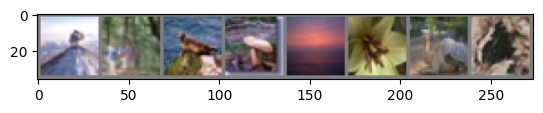

Predicted: ['skyscraper', 'palm_tree', 'shark', 'motorcycle', 'sea', 'lobster', 'wolf', 'porcupine']
Actual: ['mountain', 'forest', 'seal', 'mushroom', 'sea', 'tulip', 'camel', 'butterfly']


In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Function to show images
def imshow(img):
    img = img / 2 + 0.5  # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# Get a batch of test images
dataiter = iter(testloader)
images, labels = next(dataiter)

# Predict
outputs = model(images)
_, predicted = torch.max(outputs, 1)

# Show images
imshow(torchvision.utils.make_grid(images[:8]))
print("Predicted:", [trainset.classes[i] for i in predicted[:8]])
print("Actual:", [trainset.classes[i] for i in labels[:8]])


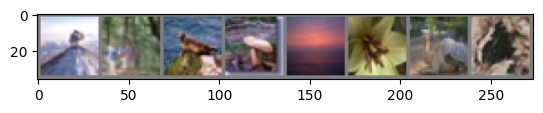

Predicted: ['skyscraper', 'palm_tree', 'shark', 'motorcycle', 'sea', 'lobster', 'wolf', 'porcupine']
Actual: ['mountain', 'forest', 'seal', 'mushroom', 'sea', 'tulip', 'camel', 'butterfly']


In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Function to show images
def imshow(img):
    img = img / 2 + 0.5  # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# Get a batch of test images
dataiter = iter(testloader)
images, labels = next(dataiter)

# Predict
outputs = model(images)
_, predicted = torch.max(outputs, 1)

# Show images
imshow(torchvision.utils.make_grid(images[:8]))
print("Predicted:", [trainset.classes[i] for i in predicted[:8]])
print("Actual:", [trainset.classes[i] for i in labels[:8]])


In [12]:
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

trainset = torchvision.datasets.CIFAR100(root='./data', train=True, download=True, transform=transform_train)
testset = torchvision.datasets.CIFAR100(root='./data', train=False, download=True, transform=transform_test)


In [13]:
#improvised model for higher accuracy
class ImprovedCNN(nn.Module):
    def __init__(self):
        super(ImprovedCNN, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.layer2 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.layer3 = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.fc1 = nn.Linear(256 * 4 * 4, 512)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, 100)

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = x.view(-1, 256 * 4 * 4)
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x


In [14]:
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])


In [15]:
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)


In [16]:
import torch

model.eval()  # set model to evaluation mode
test_loss = 0.0
correct = 0
total = 0

criterion = nn.CrossEntropyLoss()

with torch.no_grad():
    for images, labels in testloader:
        outputs = model(images)
        loss = criterion(outputs, labels)
        test_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

avg_loss = test_loss / len(testloader)
accuracy = 100 * correct / total

print(f"Test Loss: {avg_loss:.4f}")
print(f"Accuracy: {accuracy:.2f}%")


Test Loss: 9.1445
Accuracy: 33.89%


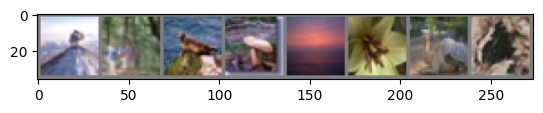

Predicted: ['skyscraper', 'palm_tree', 'shark', 'motorcycle', 'sea', 'lobster', 'wolf', 'porcupine']
Actual: ['mountain', 'forest', 'seal', 'mushroom', 'sea', 'tulip', 'camel', 'butterfly']


In [17]:
import matplotlib.pyplot as plt
import numpy as np

# Function to show images
def imshow(img):
    img = img / 2 + 0.5  # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# Get a batch of test images
dataiter = iter(testloader)
images, labels = next(dataiter)

# Predict
outputs = model(images)
_, predicted = torch.max(outputs, 1)

# Show images
imshow(torchvision.utils.make_grid(images[:8]))
print("Predicted:", [trainset.classes[i] for i in predicted[:8]])
print("Actual:", [trainset.classes[i] for i in labels[:8]])
